In [8]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt

In [9]:
# custom values
EDGE_LENGTH = 1e-2
ANGLE_OFFSET = np.pi/12
EDGE_OFFSET = 1e-5

# given paramters
RR = 0.06
BS = 0.004
RK = 0.02

POTENTIAL_ANGLE = 10 * np.pi/180   # in rad

POTENTIAL_1 = 1     # V
POTENTIAL_2 = -1    # V

In [10]:
# points on the inner circle
angle_5 = np.arccos(0.5*BS / RK)
height_5 = np.sin(angle_5) * RK

# points on the outer circle
angle_6 = np.arccos(0.5*BS / RR)
height_6 = np.sin(angle_6) * RR
angle_13 = np.pi - angle_6
angle_17 = angle_6 + np.pi
angle_3 = angle_13 + np.pi  # oder # angle_3 = -np.pi + angle_6

# potential parts on the outer circle
angle_11 = np.pi - 0.25*np.pi - 0.5*POTENTIAL_ANGLE
angle_12 = angle_11 + 0.5*POTENTIAL_ANGLE
angle_9 = angle_11 + np.pi
# angle_10 = angle_12 + np.pi 
angle_10 = 0 - 0.25*np.pi + 0.5*POTENTIAL_ANGLE
# angle_12 + np.pi

### Outer Circle

In [11]:
nodes, elements = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_10, a_max=angle_11)

# from p11 to p12
nodes2, elements2 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_11, a_max=angle_12)
nodes, elements = mt.AddSegments(nodes, nodes2)

# from p12 to p9
nodes3, elements3 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_12, a_max=angle_9)
nodes, elements = mt.AddSegments(nodes, nodes3)

# from p9 to p10
# nodes4, elements4 = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_9, a_max=angle_10-ANGLE_OFFSET)
# nodes, elements = mt.AddSegments(nodes, nodes4)

In [12]:
# nodes, elements = mt.CircleSegments([0,0], RR, edge_length=EDGE_LENGTH, a_min=angle_9, a_max=angle_10)

### Inner Circle

In [ ]:
nodes8, elements8 = mt.CircleSegments([0,0], RK, edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes8, elements8)

# from p6 to p5
nodes9, elements9 = mt.LineSegments([0.5*BS, height_6-EDGE_OFFSET], [0.5*BS, height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes9, elements9)

# from p13 to p14
nodes10, elements10 = mt.LineSegments([-0.5*BS, height_6-EDGE_OFFSET], [-0.5*BS, height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes10, elements10)

# from p3 to p4
nodes11, elements11 = mt.LineSegments([0.5*BS, -height_6-EDGE_OFFSET], [0.5*BS, -height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes11, elements11)

# from p17 to p16
nodes12, elements12 = mt.LineSegments([-0.5*BS, -height_6-EDGE_OFFSET], [-0.5*BS, -height_5], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes12, elements12)

### Create Mesh

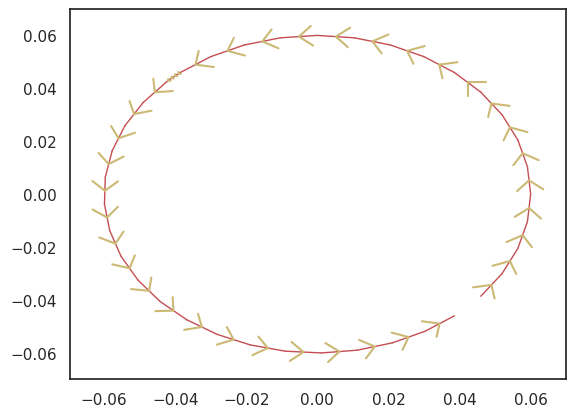

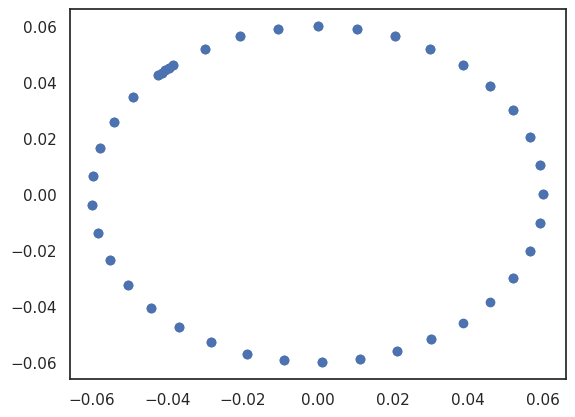

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [14]:
mt.PlotBoundary(nodes, elements, btype="Segments")
plt.show()
mt.PlotBoundary(nodes, elements, btype="Nodes")
plt.show()
knots, triangles,BouE,li_BE,bou_elem,CuE,li_CE = mt.DoTriMesh(nodes, elements, edge_length=EDGE_LENGTH)